# TO DO: Encapsulate the code and generate the results for large. range of lambda
# Study the case of averaging the preditctions
# See if we can study why this works theoretically

In [1]:
import os
import netCDF4 as netcdf
import numpy as np
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/src")

PATH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Training-Ext/Omon/tos'

In [2]:
DIR_LIST = os.listdir(PATH)

dic_data = {}
dic_forced_response = {}

# how to center the data with respect to the monthly mean

# 1. calculate the monthly mean
# 2. subtract the monthly mean from the data
# 3. calculate the forced response by averaging over the time dimension

for idx_m, dir in enumerate(DIR_LIST):

    print(f'Processing {idx_m+1}/{len(DIR_LIST)}: {dir}')
    dir_path = os.path.join(PATH, dir)
    file_list = os.listdir(dir_path)

    dic_data[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)
    dic_forced_response[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)

    for idx_f, file in enumerate(file_list):
        print(f'  Processing {idx_f+1}/{len(file_list)}: {file}')
        file_path = os.path.join(dir_path, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        dic_data[dir][idx_f,:,:,:] = np.array(netcdf_file.variables['tos']) 
        for i in range(12):
            dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] = dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(dic_data[dir][idx_f, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        # print(f'  Tas shape: {tas.shape}')
    dic_forced_response[dir][:,:,:,:] = np.nanmean(dic_data[dir], axis=0)
    

Processing 1/5: CESM2
  Processing 1/50: tos_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc


/home/vcohen/.conda/envs/cope/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  Processing 2/50: tos_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: tos_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: tos_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: tos_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: tos_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: tos_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: tos_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: tos_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: tos_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: tos_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: tos_mon_CESM2_historical_ssp370_r1111.006i1p1f1.188001-210012.nc
  Processing 13/50: tos_mon_CESM2_historical_ssp370_r1251.019i1p1f1.18800

In [3]:
# read the test data
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'


DIR_LIST_TEST = os.listdir(PATH_EVAL)


lst_test_name = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
lst_test_name = ['B', 'D', 'E', 'G','J']

data_test = np.zeros((len(lst_test_name), 876, 72, 144), dtype=np.float32)


for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tos_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])
        if file[9] in lst_test_name:
            # find position of file[9] in lst_test_name
            idx_test = lst_test_name.index(file[9])
            print(f'  Found test data for {file[9]} at index {idx_test}')
            data_test[idx_test,:,:,:] = np.array(netcdf_file.variables['tos']) 
        
            for i in range(12):
                data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)


  Processing 21/81: tos_mon_1D.195001-202212.nc
  Found test data for D at index 1
  Processing 27/81: tos_mon_1C.195001-202212.nc
  Processing 32/81: tos_mon_1H.195001-202212.nc
  Processing 45/81: tos_mon_1G.195001-202212.nc
  Found test data for G at index 3
  Processing 51/81: tos_mon_1B.195001-202212.nc
  Found test data for B at index 0
  Processing 57/81: tos_mon_1I.195001-202212.nc
  Processing 67/81: tos_mon_1F.195001-202212.nc
  Processing 72/81: tos_mon_1J.195001-202212.nc
  Found test data for J at index 4
  Processing 78/81: tos_mon_1A.195001-202212.nc
  Processing 81/81: tos_mon_1E.195001-202212.nc
  Found test data for E at index 2


In [4]:
# Read the ground truth data
PATH_GROUND_TRUTH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ensmeans-Tier1'

DIR_LIST_GROUND_TRUTH = os.listdir(PATH_GROUND_TRUTH)

lst_test_name = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
lst_test_name = ['B', 'D', 'E', 'G','J']

data_ground_truth_test = np.zeros((len(lst_test_name), 876, 72, 144), dtype=np.float32)

count = 0 
for idx_r, file in enumerate(DIR_LIST_GROUND_TRUTH):

    if file.__contains__('.tos.'):
        
        print(f'  Processing {idx_r+1}: {file}')

        # read the ground truth data
        file_path = os.path.join(PATH_GROUND_TRUTH, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')


        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        if file[1] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[1])
            print(f'  Found test data for {file[1]} at index {idx_test}')
            data_ground_truth_test[idx_test,:,:,:] = np.array(netcdf_file.variables['arr_EM'])

            for i in range(12):
                data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_ground_truth_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)


  Processing 8: 1A.tos.EM.1950-2022.nc
  Processing 16: 1B.tos.EM.1950-2022.nc
  Found test data for B at index 0
  Processing 24: 1C.tos.EM.1950-2022.nc
  Processing 32: 1D.tos.EM.1950-2022.nc
  Found test data for D at index 1
  Processing 40: 1E.tos.EM.1950-2022.nc
  Found test data for E at index 2
  Processing 48: 1F.tos.EM.1950-2022.nc
  Processing 56: 1G.tos.EM.1950-2022.nc
  Found test data for G at index 3
  Processing 64: 1H.tos.EM.1950-2022.nc
  Processing 72: 1J.tos.EM.1950-2022.nc
  Found test data for J at index 4


In [5]:
def get_nans(data):
    """ Get the nans from the data and return the indices of non-nan and nan values.
                           
        Args: 
            data: Dictionary of raw data (indexed by models and subdictionary indexed by runs)
            
        Returns:
            notnan_idx, nan_idx: non nan indices and nan indices i
    """
    # record nan indices as the union of nans on each map
    nan_idx = []

    for idx_m,m in enumerate(data.keys()):

        # capture nan indices and record the union of nans
        for i in range(data[m].shape[0]):
            nan_idx_tmp = list(np.where(data[m][i,0,:,:].ravel() < -1e9)[0])
            nan_idx = list(set(nan_idx) | set(nan_idx_tmp))


    # get longitude and latitude size
    lon_size = longitude.shape[0]
    lat_size = latitude.shape[0]    

    # define not nan indices (useful to ease the computations)
    notnan_idx = list(set(list(range(lon_size*lat_size))) - set(nan_idx))

    return notnan_idx, nan_idx

In [6]:
notnan_idx, nan_idx = get_nans(dic_data)

In [7]:
# get the estimates of the other participants 

# Read the estimates of the other methods
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ForceSMIP-estimates-Tier1'

DIR_LIST_TEST = os.listdir(PATH_TEST)
data_estimates = np.zeros((30,len(lst_test_name), 876, 72, 144), dtype=np.float32)

count = 0
for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tos_'):

        # read the test data
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_TEST, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')


        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])
        if file[5] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[5])
            print(f'  Found test data for {file[5]} at index {idx_test}')
            data_estimates[:,idx_test,:,:,:] = np.array(netcdf_file.variables['forced_component']) 

        print(f'  Tas shape: {data_estimates[:,idx_test,:,:,:].shape}')


lst_to_center = [8,9,14,24]

# center the methods that are not centered
for idx_m in lst_to_center:
    print(f'Centering data for method {idx_m}')
    for i in range(12):
        data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] = data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_estimates[idx_m,:, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)


  Processing 61/80: tos_1A_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 62/80: tos_1B_1950_2022.nc
  Found test data for B at index 0
  Tas shape: (30, 876, 72, 144)
  Processing 63/80: tos_1C_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 64/80: tos_1D_1950_2022.nc
  Found test data for D at index 1
  Tas shape: (30, 876, 72, 144)
  Processing 65/80: tos_1E_1950_2022.nc
  Found test data for E at index 2
  Tas shape: (30, 876, 72, 144)
  Processing 66/80: tos_1F_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 67/80: tos_1G_1950_2022.nc
  Found test data for G at index 3
  Tas shape: (30, 876, 72, 144)
  Processing 68/80: tos_1H_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 69/80: tos_1I_1950_2022.nc
  Tas shape: (30, 876, 72, 144)
  Processing 70/80: tos_1J_1950_2022.nc
  Found test data for J at index 4
  Tas shape: (30, 876, 72, 144)
Centering data for method 8


/tmp/ipykernel_20405/1761275155.py:40: RuntimeWarning: Mean of empty slice
  data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] = data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_estimates[idx_m,:, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)


Centering data for method 9
Centering data for method 14
Centering data for method 24


In [8]:
import torch

def normalize_data(data, means, vars):
    """Normalize the data with respect to the monthly mean and the variance of the anomaly.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           means: numpy array of shape (runs, latitude, longitude)
           vars: numpy array of shape (runs, latitude, longitude)
       Return:
           normalized_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    normalized_data = {}
    for idx,key in enumerate(data.keys()):
        normalized_data[key] = (data[key] - means[key]) / np.sqrt(vars[key])
    return normalized_data

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = torch.from_numpy(x[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        y_train[m] = torch.from_numpy(y[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [9]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)


# Compute the yearly average for each key in the dictionary
def compute_yearly_average(data, months_per_year=12):
    """
    Compute the yearly average of a dictionary of numpy arrays.
    Args:
        data: dictionary of numpy arrays
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        dictionary of numpy arrays with yearly averages
    """
    yearly_data = {}
    for key, m in enumerate(data.keys()):
        yearly_data[m] = yearly_average(data[m], months_per_year)

    return yearly_data

In [10]:
# # check if the data is correct by plotting the ensemble mean and the evaluation data on the same plot
# import matplotlib.pyplot as plt

# idx_run = 0
# idx_lat = 30
# idx_lon = 30

# x_tmp = data_ground_truth_test[idx_run,:,idx_lat,idx_lon]
# y_tmp = data_test[idx_run,:,idx_lat,idx_lon]

# plt.figure(figsize=(10, 5))
# plt.plot(x_tmp, label='Ground Truth', color='red')
# plt.plot(y_tmp, label='Evaluation', color='blue')
# plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
# plt.xlabel('Time')
# plt.ylabel('Temperature')
# plt.legend()
# plt.show()

In [11]:
# Train the model on the yearly data
dic_data_yearly = compute_yearly_average(dic_data, months_per_year=12)
dic_forced_response_yearly = compute_yearly_average(dic_forced_response, months_per_year=12)

x_test_yearly = torch.from_numpy(yearly_average(data_test, months_per_year=12).reshape(data_test.shape[0], data_test.shape[1] // 12, -1))
y_test_yearly = torch.from_numpy(yearly_average(data_ground_truth_test, months_per_year=12).reshape(data_ground_truth_test.shape[0], data_ground_truth_test.shape[1] // 12, -1))

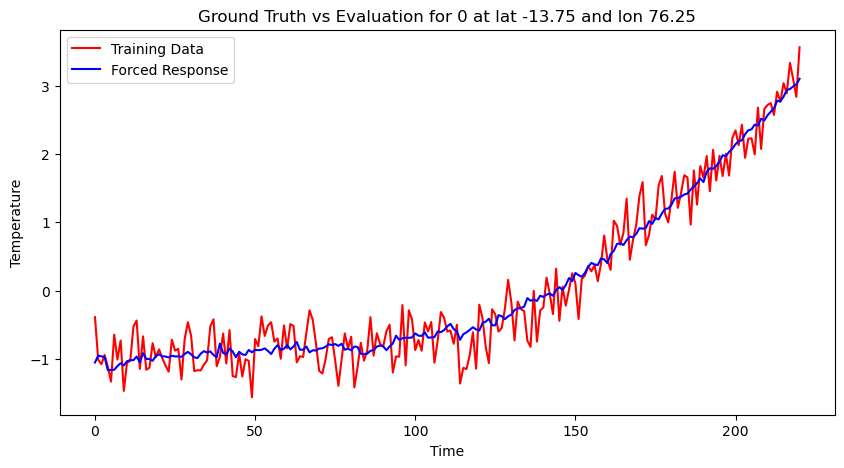

In [12]:
import matplotlib.pyplot as plt

# plot time series in a single grid cell
idx_run = 0
idx_lat = 30
idx_lon = 30
plt.figure(figsize=(10, 5))
plt.plot(dic_data_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Training Data', color='red')
plt.plot(dic_forced_response_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Forced Response', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [ ]:
# compute the variance of anomaly per climate model and standardize
means_yearly = {}
vars_yearly = {}
vars = {}
means = {}

# for each model, compute the variance of the anomaly
for dir in DIR_LIST:
    print(f'Computing variance for {dir}')
    # means_yearly[dir] = np.nanmean(dic_data_yearly[dir], axis=0)
    means_yearly[dir] =  np.zeros((dic_data_yearly[dir].shape[1], dic_data_yearly[dir].shape[2], dic_data_yearly[dir].shape[3]), dtype=np.float32)
    vars_yearly[dir] = np.nanvar(dic_data_yearly[dir], axis=0)
    vars[dir] = np.nanvar(dic_data[dir], axis=0)
    means[dir] = np.zeros((dic_data[dir].shape[1], dic_data[dir].shape[2], dic_data[dir].shape[3]), dtype=np.float32)


# normalize the data
# dic_data_tmp = normalize_data(dic_data, means, vars)
# dic_forced_response_tmp = normalize_data(dic_forced_response, means, vars)

# dic_data_yearly_tmp = normalize_data(dic_data_yearly, means_yearly, vars_yearly)
# dic_forced_response_yearly_tmp= normalize_data(dic_forced_response_yearly, means_yearly, vars_yearly)

Computing variance for CESM2


/home/vcohen/.conda/envs/cope/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1741: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


Computing variance for CanESM5
Computing variance for MIROC-ES2L
Computing variance for MIROC6
Computing variance for MPI-ESM1-2-LR


/tmp/ipykernel_20405/456926308.py:14: RuntimeWarning: divide by zero encountered in divide
  normalized_data[key] = (data[key] - means[key]) / np.sqrt(vars[key])


In [ ]:
# train the models on yearly data
# compute training set and test set

x_train_yearly, y_train_yearly  = merge_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)
# x_train_yearly_tmp, y_train_yearly_tmp  = merge_training_data(dic_data_yearly_tmp,dic_forced_response_yearly_tmp,dtype=torch.float32)

x_yearly, y_yearly = reshape_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)

  x_train shape: torch.Size([11050, 10368])
  x_train shape: torch.Size([16575, 10368])
  x_train shape: torch.Size([23205, 10368])
  x_train shape: torch.Size([34255, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([11050, 10368])
  x_train shape: torch.Size([16575, 10368])
  x_train shape: torch.Size([23205, 10368])
  x_train shape: torch.Size([34255, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([25, 221, 10368])
  y_train shape: torch.Size([25, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])


In [15]:
# Evaluate the model on test data
x_test = torch.from_numpy(data_test).to(torch.float32).reshape(data_test.shape[0],data_test.shape[1],data_test.shape[2]*data_test.shape[3])
y_test = torch.from_numpy(data_ground_truth_test).to(torch.float32).reshape(data_test.shape[0],data_test.shape[1],data_test.shape[2]*data_test.shape[3])

In [16]:
# add the new nan indices
# record nan indices as the union of nans on each map
nan_idx_test = nan_idx.copy()

for idx_r in range(x_test.shape[0]):

    nan_idx_test = list(set(nan_idx_test) | set(list(np.where(x_test[idx_r,0,:].ravel() < -1e10 )[0])))    
    # define not nan indices (useful to ease the computations)
notnan_idx_test = list(set(list(range(x_test.shape[2]))) - set(nan_idx_test))


# replace the nan index by Nans
notnan_idx = notnan_idx_test
nan_idx = nan_idx_test

In [ ]:
# replace the nan index by Nans
x_train_yearly[:,nan_idx] = float('nan')
# x_train_yearly_tmp[:,nan_idx] = float('nan')
x_test[:,:,nan_idx] = float('nan')

y_train_yearly[:,nan_idx] = float('nan')
# y_train_yearly_tmp[:,nan_idx] = float('nan')
y_test[:,:,nan_idx] = float('nan')

In [18]:
# we add the saptial mean as indicator of the time index, this can help the model to learn the temporal dynamics
x_train_yearly_new = np.c_[x_train_yearly,np.zeros(x_train_yearly.shape[0])]
x_train_yearly_new[:,-1] = np.nanmean(x_train_yearly, axis=1)

y_train_yearly_new = np.c_[y_train_yearly,np.zeros(y_train_yearly.shape[0])]
y_train_yearly_new[:,-1] = np.nanmean(y_train_yearly, axis=1)

x_train_yearly_new = torch.from_numpy(x_train_yearly_new).to(torch.float32)
y_train_yearly_new = torch.from_numpy(y_train_yearly_new).to(torch.float32)

x_train_yearly_new[:,nan_idx] = float('nan')
y_train_yearly_new[:,nan_idx] = float('nan')

In [19]:
x_test_new = torch.zeros((x_test.shape[0], x_test.shape[1], x_test.shape[2]+1), dtype=torch.float32)
for i in range(x_test.shape[0]):
    x_test_new[i,:,:-1] = x_test[i,:,:]
    x_test_new[i,:,-1] = torch.nanmean(x_test[i,:,:], axis=1)

In [20]:
notnan_idx_new = notnan_idx.copy()
notnan_idx_new.append(x_test.shape[2])

In [21]:
from algorithms import ridge_regression, ridge_regression_low_rank


# penalty parameters
lambda_tmp = 2000.0


# ridge regression
w_ridge = torch.zeros((x_train_yearly.shape[1], y_train_yearly.shape[1]), dtype=torch.float32)
w_ridge[np.ix_(notnan_idx,notnan_idx)] = ridge_regression(x_train_yearly[:,notnan_idx], y_train_yearly[:,notnan_idx], lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

# low rank regression
U,S,V = torch.linalg.svd(x_train_yearly[:,notnan_idx]@w_ridge[np.ix_(notnan_idx,notnan_idx)],full_matrices=False)

rank = 5
w_ridge_low_rank = torch.zeros((x_train_yearly.shape[1], y_train_yearly.shape[1]), dtype=torch.float32)
w_ridge_low_rank[np.ix_(notnan_idx,notnan_idx)] = w_ridge[np.ix_(notnan_idx,notnan_idx)] @ V[:rank,:].T@V[:rank,:]

Loss function:  112317.71875


In [22]:
# # penalty parameters
# lambda_tmp = 5000.0


# # ridge regression on the new data
# w_ridge_new = torch.zeros((x_train_yearly_new.shape[1], y_train_yearly_new.shape[1]), dtype=torch.float32)
# w_ridge_new[np.ix_(notnan_idx_new,notnan_idx_new)] = ridge_regression(x_train_yearly_new[:,notnan_idx_new], y_train_yearly_new[:,notnan_idx_new], lambda_= lambda_tmp, verbose=True, dtype=torch.float32)


# # low rank regression on the new data
# U,S,V = torch.linalg.svd(x_train_yearly_new[:,notnan_idx_new]@w_ridge_new[np.ix_(notnan_idx_new,notnan_idx_new)],full_matrices=False)


# rank = 3
# w_ridge_low_rank_new = torch.zeros((x_train_yearly_new.shape[1], y_train_yearly_new.shape[1]), dtype=torch.float32)
# w_ridge_low_rank_new[np.ix_(notnan_idx_new,notnan_idx_new)] = w_ridge_new[np.ix_(notnan_idx_new,notnan_idx_new)] @ V[:rank,:].T@V[:rank,:]

In [23]:
# # preditcion on test data
# y_pred_new = torch.zeros((x_test_new.shape[0], x_test_new.shape[1], x_test_new.shape[2]), dtype=torch.float32)
# y_pred_new[:,:,notnan_idx_new] = x_test_new[:,:,notnan_idx_new] @ w_ridge_new[np.ix_(notnan_idx_new,notnan_idx_new)]

# # prediction with low rank ridge regression
# y_pred_lr_new = torch.zeros((x_test_new.shape[0], x_test_new.shape[1], x_test_new.shape[2]), dtype=torch.float32)
# y_pred_lr_new[:,:,notnan_idx_new] = x_test_new[:,:,notnan_idx_new] @ w_ridge_low_rank_new[np.ix_(notnan_idx_new,notnan_idx_new)]


# rmse_new = torch.sqrt(torch.nanmean((y_pred_lr_new[:,:,:-1] - y_test) ** 2,axis=(1,2))).detach().numpy()
# rmse_low_rank_new = torch.sqrt(torch.nanmean((y_pred_lr_new[:,:,:-1] - y_test) ** 2,axis=(1,2))).detach().numpy()

# print(f'MSE Ridge Regression: {rmse_new}')
# print(f'MSE Low Rank Ridge Regression: {rmse_low_rank_new}')

In [28]:
# preditcion on test data
y_pred = torch.zeros((x_test.shape[0], x_test.shape[1], x_test.shape[2]), dtype=torch.float32)
y_pred[:,:,notnan_idx] = x_test[:,:,notnan_idx] @ w_ridge[np.ix_(notnan_idx,notnan_idx)]
y_pred_yearly = y_pred.reshape(y_pred.shape[0], y_pred.shape[1] // 12, 12, y_pred.shape[2])
y_pred_yearly = y_pred_yearly.nanmean(axis=2)


# prediction with low rank ridge regression
y_pred_lr = torch.zeros((x_test.shape[0], x_test.shape[1], x_test.shape[2]), dtype=torch.float32)
y_pred_lr[:,:,notnan_idx] = x_test[:,:,notnan_idx] @ w_ridge_low_rank[np.ix_(notnan_idx,notnan_idx)]
y_pred_lr_yearly = y_pred_lr.reshape(y_pred_lr.shape[0], y_pred_lr.shape[1] // 12, 12, y_pred_lr.shape[2])
y_pred_lr_yearly = y_pred_lr_yearly.nanmean(axis=2)



rmse_yearly = torch.sqrt(torch.nanmean((y_pred_yearly[:,:,notnan_idx] - y_test_yearly[:,:,notnan_idx]) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_yearly = torch.sqrt(torch.nanmean((y_pred_lr_yearly[:,:,notnan_idx] - y_test_yearly[:,:,notnan_idx]) ** 2,axis=(1,2))).detach().numpy()


print(f'MSE Ridge Regression Yearly: {rmse_yearly}')
print(f'MSE Low Rank Ridge Regression Yearly: {rmse_low_rank_yearly}')

MSE Ridge Regression Yearly: [0.13352366 0.20764506 0.1260683  0.1403881  0.11864092]
MSE Low Rank Ridge Regression Yearly: [0.13608073 0.21015061 0.13823448 0.14094661 0.12313181]


In [29]:
data_estimates_tmp = data_estimates.reshape(data_estimates.shape[0],data_estimates.shape[1],data_estimates.shape[2],data_estimates.shape[3]*data_estimates.shape[4])
data_ground_truth_test_tmp = data_ground_truth_test.reshape(data_ground_truth_test.shape[0],data_ground_truth_test.shape[1],data_ground_truth_test.shape[2]*data_ground_truth_test.shape[3])

In [31]:
# compute mse of the other estimates
mse_estimates = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))

for idx_r in range(data_estimates.shape[0]):
    mse_estimates[idx_r,:] = np.sqrt(np.nanmean((data_estimates_tmp[idx_r,:,:,notnan_idx].transpose(1,2,0) - data_ground_truth_test_tmp[:,:,notnan_idx]) ** 2,axis=(1,2))) 
    print(f'  MSE estimates: {mse_estimates[idx_r,:]}')

  MSE estimates: [0.26515353 0.45298886 0.23926461 0.30716702 0.20178227]
  MSE estimates: [0.24668823 0.3926945  0.23955144 0.2651298  0.18227246]
  MSE estimates: [0.22568692 0.43880808 0.19529693 0.25151205 0.17101932]
  MSE estimates: [0.38486251 0.25517273 0.32583562 0.27897114 0.28570169]
  MSE estimates: [0.18075012 0.24434634 0.19196312 0.23851666 0.16404581]
  MSE estimates: [0.15559337 0.20051481 0.16405053 0.20613751 0.15014708]
  MSE estimates: [0.17867574 0.38370138 0.17531215 0.22668715 0.13945486]
  MSE estimates: [0.19291571 0.39176118 0.17016703 0.244776   0.14638798]
  MSE estimates: [0.15276821 0.21315137 0.16435786 0.21214262 0.14746155]
  MSE estimates: [0.45327917 0.54831296 0.40221784 0.50830483 0.36170739]
  MSE estimates: [0.22025053 0.42251879 0.19119439 0.25085142 0.17395896]
  MSE estimates: [0.18373856 0.35418716 0.17740801 0.23686296 0.14390624]
  MSE estimates: [0.18547171 0.35701838 0.1763768  0.23637511 0.14740597]
  MSE estimates: [0.18861136 0.4175144

In [32]:
# compute the yearly estimates of each method
data_estimates_yearly = data_estimates.reshape(data_estimates.shape[0],data_estimates.shape[1],data_estimates.shape[2] // 12, 12, longitude.shape[0]*latitude.shape[0])
data_estimates_yearly = np.nanmean(data_estimates_yearly, axis=3)

data_ground_truth_test_yearly = data_ground_truth_test.reshape(data_ground_truth_test.shape[0],data_ground_truth_test.shape[1] // 12, 12, longitude.shape[0]*latitude.shape[0])
data_ground_truth_test_yearly = np.nanmean(data_ground_truth_test_yearly, axis=2)

/home/vcohen/.conda/envs/cope/lib/python3.9/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_20405/1635170714.py:3: RuntimeWarning: Mean of empty slice
  data_estimates_yearly = np.nanmean(data_estimates_yearly, axis=3)
/tmp/ipykernel_20405/1635170714.py:6: RuntimeWarning: Mean of empty slice
  data_ground_truth_test_yearly = np.nanmean(data_ground_truth_test_yearly, axis=2)


In [34]:
# compute mse of the other estimates yearly
mse_estimates_yearly = np.zeros((data_estimates_yearly.shape[0],data_estimates_yearly.shape[1])) 
for idx_r in range(data_estimates_yearly.shape[0]):
    mse_estimates_yearly[idx_r,:] = np.sqrt(np.nanmean((data_estimates_yearly[idx_r,:,:,:] - data_ground_truth_test_yearly) ** 2,axis=(1,2))) 
    print(f'  MSE estimates yearly: {mse_estimates_yearly[idx_r,:]}')

  MSE estimates yearly: [0.24353725 0.42950669 0.20472381 0.25650328 0.18404005]
  MSE estimates yearly: [0.19877562 0.34378198 0.16671908 0.1917201  0.14912054]
  MSE estimates yearly: [0.18495046 0.39476517 0.14882469 0.18547696 0.13858666]
  MSE estimates yearly: [0.34902081 0.20723836 0.29342026 0.20960799 0.24672723]
  MSE estimates yearly: [0.1446708  0.19464092 0.14187558 0.16231427 0.13724343]
  MSE estimates yearly: [0.12095136 0.15633632 0.12300538 0.13761675 0.12521969]
  MSE estimates yearly: [0.14124978 0.35690838 0.12234523 0.14770962 0.10908042]
  MSE estimates yearly: [0.15689887 0.35946625 0.11755705 0.17015977 0.11644145]
  MSE estimates yearly: [0.11953878 0.17247009 0.12255248 0.14692186 0.12470189]
  MSE estimates yearly: [0.27683866 0.38548076 0.22973941 0.27944869 0.21097673]
  MSE estimates yearly: [0.19198726 0.39745826 0.14938805 0.19303927 0.1480965 ]
  MSE estimates yearly: [0.15136024 0.32343853 0.12699834 0.16534807 0.11723828]
  MSE estimates yearly: [0.1

In [35]:
# get the statistics of the estimates and the predictions
stats_mse_estimates = {}
stats_mse_estimates['mean'] = np.zeros(mse_estimates_yearly.shape[0]+5)
stats_mse_estimates['median'] = np.zeros(mse_estimates_yearly.shape[0]+5)
stats_mse_estimates['75th'] = np.zeros(mse_estimates_yearly.shape[0]+5)
stats_mse_estimates['90th'] = np.zeros(mse_estimates_yearly.shape[0]+5)
stats_mse_estimates['95th'] = np.zeros(mse_estimates_yearly.shape[0]+5)
stats_mse_estimates['worst-case'] = np.zeros(mse_estimates_yearly.shape[0]+5)
stats_mse_estimates['variance'] = np.zeros(mse_estimates_yearly.shape[0]+5)


for idx_r in range(data_estimates.shape[0]):
    # compute the mse of the estimates

    stats_mse_estimates['mean'][idx_r] = np.mean(mse_estimates_yearly[idx_r,:], axis=0)
    stats_mse_estimates['median'][idx_r] = np.median(mse_estimates_yearly[idx_r,:], axis=0)
    stats_mse_estimates['75th'][idx_r] = np.quantile(mse_estimates_yearly[idx_r,:], 0.75, axis=0)
    stats_mse_estimates['90th'][idx_r] = np.quantile(mse_estimates_yearly[idx_r,:], 0.90, axis=0)
    stats_mse_estimates['95th'][idx_r] = np.quantile(mse_estimates_yearly[idx_r,:], 0.95, axis=0)
    stats_mse_estimates['worst-case'][idx_r] = np.max(mse_estimates_yearly[idx_r,:], axis=0)
    stats_mse_estimates['variance'][idx_r] = np.var(mse_estimates_yearly[idx_r,:], axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]] = np.mean(rmse_yearly, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]] = np.median(rmse_yearly, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]] = np.quantile(rmse_yearly, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]] = np.quantile(rmse_yearly, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]] = np.quantile(rmse_yearly, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]] = np.max(rmse_yearly, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]] = np.var(rmse_yearly, axis=0)



stats_mse_estimates['mean'][data_estimates.shape[0]+1] = np.mean(rmse_low_rank_yearly, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+1] = np.median(rmse_low_rank_yearly, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank_yearly, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank_yearly, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+1] = np.quantile(rmse_low_rank_yearly, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+1] = np.max(rmse_low_rank_yearly, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+1] = np.var(rmse_low_rank_yearly, axis=0)

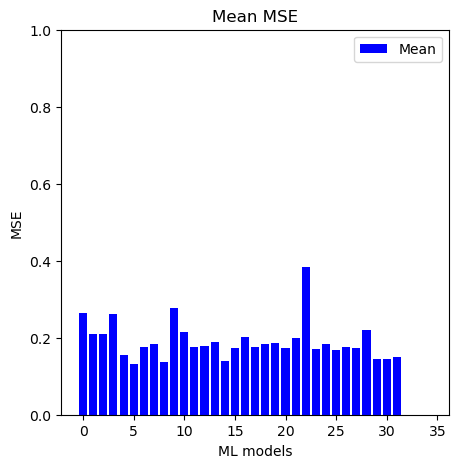

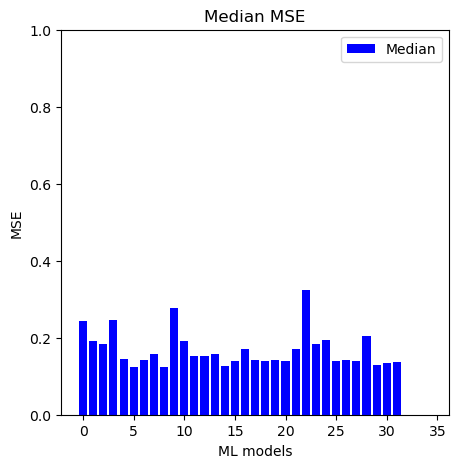

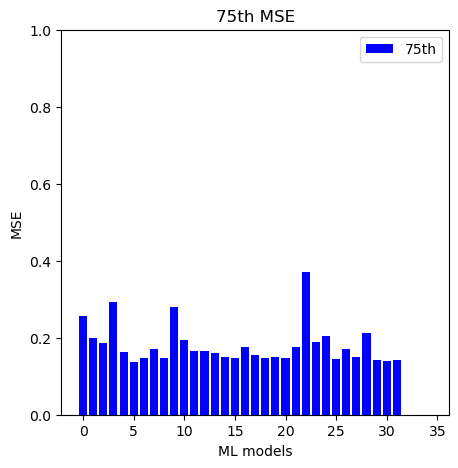

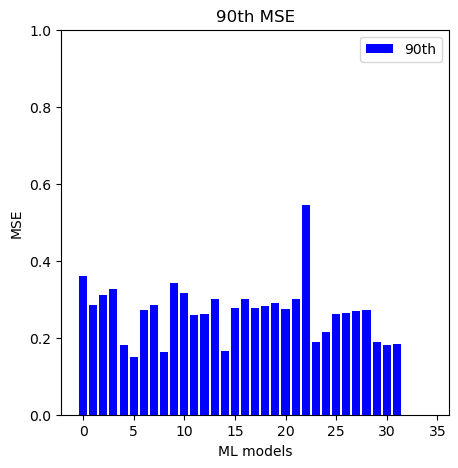

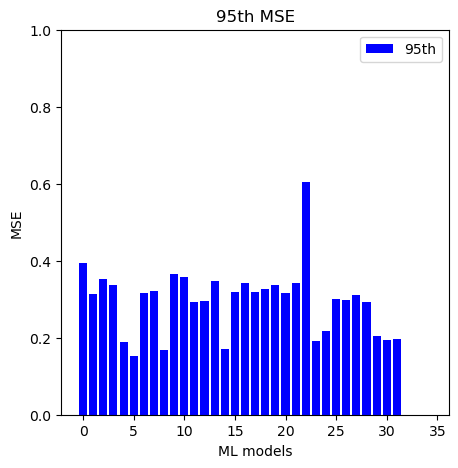

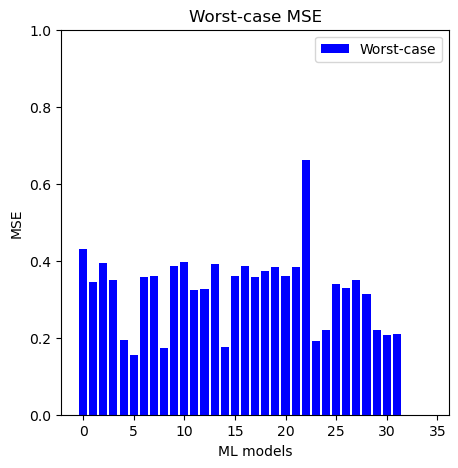

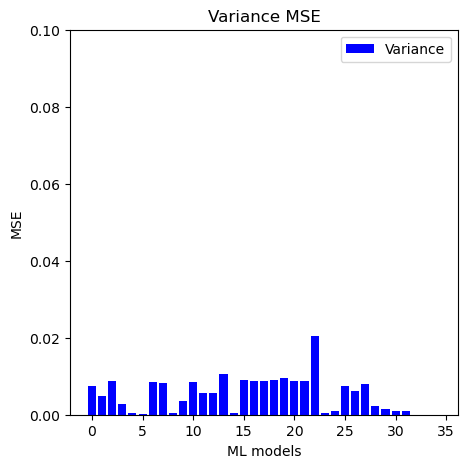

In [36]:
# display the statistica as bar plot

#plot the mean
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['mean'])), stats_mse_estimates['mean'], color='blue', label='Mean')
plt.title('Mean MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the median
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['median'])), stats_mse_estimates['median'], color='blue', label='Median')
plt.title('Median MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the 75th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['75th'])), stats_mse_estimates['75th'], color='blue', label='75th')
plt.title('75th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 90th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['90th'])), stats_mse_estimates['90th'], color='blue', label='90th')
plt.title('90th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 95th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['95th'])), stats_mse_estimates['95th'], color='blue', label='95th')
plt.title('95th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

# plot the worst-case
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['worst-case'])), stats_mse_estimates['worst-case'], color='blue', label='Worst-case')
plt.title('Worst-case MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()


# plot the variance
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['variance'])), stats_mse_estimates['variance'], color='blue', label='Variance')
plt.title('Variance MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0,0.1)
plt.legend()
plt.show()

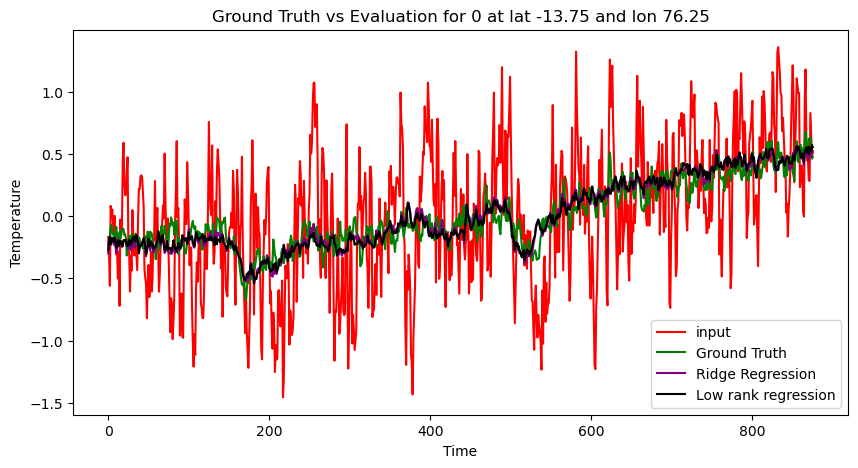

In [39]:
# plot time series in a single grid cell
idx_lat = 30
idx_lon = 30
plt.figure(figsize=(10, 5))
# plt.plot(dic_data['CESM2'][0,:,idx_lat,idx_lon], label='Training Data', color='red')
plt.plot(x_test.reshape(len(lst_test_name),y_test.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='input', color='red')
plt.plot(y_test.reshape(len(lst_test_name),y_test.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Ground Truth', color='green')
plt.plot(y_pred.reshape(len(lst_test_name),y_pred.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Ridge Regression', color='purple')
plt.plot(y_pred_lr.reshape(len(lst_test_name),y_pred_lr.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Low rank regression', color='black')
# plt.plot(y_pred_trace.reshape(len(lst_test_name),y_pred.shape[1],latitude.shape[0],longitude.shape[0])[2,:,idx_lat,idx_lon], label='Trace norm regression', color='orange')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

# Idea: Test by combining the predictions of different denoising models

In [40]:
# Test the M denoising models and weighted predictions

w_ridge_per_model = {}
w_ridge_low_rank_per_model = {}

rmse_per_model = {}
rmse_low_rank_per_model = {}

lambda_tmp = 1000.0


for dir in list(dic_data_yearly.keys()):
    print(f'Computing ridge regression for {dir}')

    # merge the corrupted data  and the original data for this specific model 
    x_train_yearly_tmp = torch.from_numpy(dic_data_yearly[dir]).to(torch.float32).reshape(dic_data_yearly[dir].shape[0]*dic_data_yearly[dir].shape[1],dic_data_yearly[dir].shape[2]*dic_data_yearly[dir].shape[3])    
    y_train_yearly_tmp = torch.from_numpy(dic_forced_response_yearly[dir]).to(torch.float32).reshape(dic_forced_response_yearly[dir].shape[0]*dic_forced_response_yearly[dir].shape[1],dic_forced_response_yearly[dir].shape[2]*dic_forced_response_yearly[dir].shape[3])


    w_ridge_per_model[dir] = torch.zeros((x_train_yearly_tmp.shape[1], y_train_yearly_tmp.shape[1]), dtype=torch.float32)
    w_ridge_per_model[dir][np.ix_(notnan_idx,notnan_idx)] = ridge_regression(x_train_yearly_tmp[:,notnan_idx], y_train_yearly_tmp[:,notnan_idx], lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

    # low rank regression
    U,S,V = torch.linalg.svd(x_train_yearly_tmp[:,notnan_idx]@w_ridge_per_model[dir][np.ix_(notnan_idx,notnan_idx)],full_matrices=False)

    # # define the rank
    rank = 20

    w_ridge_low_rank_per_model[dir] = torch.zeros((x_train_yearly_tmp.shape[1], y_train_yearly_tmp.shape[1]), dtype=torch.float32)
    w_ridge_low_rank_per_model[dir][np.ix_(notnan_idx,notnan_idx)] = w_ridge_per_model[dir][np.ix_(notnan_idx,notnan_idx)] @ V[:rank,:].T@V[:rank,:]

    # Evaluate the model on test data
    y_pred_tmp = torch.zeros_like(x_test_yearly, dtype=torch.float32)
    y_pred_tmp[:,:,notnan_idx] = x_test_yearly[:,:,notnan_idx] @ w_ridge_per_model[dir][np.ix_(notnan_idx,notnan_idx)]

    y_pred_low_rank_tmp = torch.zeros_like(x_test_yearly, dtype=torch.float32)
    y_pred_low_rank_tmp[:,:,notnan_idx] = x_test_yearly[:,:,notnan_idx] @ w_ridge_low_rank_per_model[dir][np.ix_(notnan_idx,notnan_idx)]

    # Compute the mean squared error
    rmse_per_model[dir] = torch.sqrt(torch.nanmean((y_pred_tmp[:,:,notnan_idx] - y_test_yearly[:,:,notnan_idx]) ** 2,axis=(1,2))).detach().numpy()
    rmse_low_rank_per_model[dir] = torch.sqrt(torch.nanmean((y_pred_low_rank_tmp[:,:,notnan_idx] - y_test_yearly[:,:,notnan_idx]) ** 2,axis=(1,2))).detach().numpy()


    print(f'  MSE : {rmse_per_model[dir]}')
    print(f'  MSE trace norm: {rmse_low_rank_per_model[dir]}')

Computing ridge regression for CESM2
Loss function:  447882.5
  MSE : [0.14981624 0.16912411 0.14987001 0.16603747 0.1212163 ]
  MSE trace norm: [0.15008979 0.169477   0.15033552 0.16678631 0.12193291]
Computing ridge regression for CanESM5
Loss function:  367158.46875
  MSE : [0.13437012 0.22249742 0.13968737 0.13992786 0.12962343]
  MSE trace norm: [0.13446535 0.22340488 0.14044978 0.13994527 0.13083613]
Computing ridge regression for MIROC-ES2L
Loss function:  340261.625
  MSE : [0.12869246 0.20384565 0.13293743 0.14295475 0.13406122]
  MSE trace norm: [0.12882029 0.20463331 0.13377482 0.1433184  0.13529141]
Computing ridge regression for MIROC6
Loss function:  452117.1875
  MSE : [0.130643   0.18323071 0.14053875 0.13879366 0.14153457]
  MSE trace norm: [0.13079996 0.18394004 0.14109693 0.13902691 0.1423283 ]
Computing ridge regression for MPI-ESM1-2-LR
Loss function:  339138.625
  MSE : [0.13232835 0.15963969 0.13565561 0.13585378 0.13283552]
  MSE trace norm: [0.13228902 0.160822

In [42]:
# Given the M denoising models, one can compute a convex combination of the predictions 
# based on the distance to the training data of the climate model m.

def training_losses(x, y, w):
    """
    Compute the distance of the predictions to the training data.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        y: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        w: torch.Tensor of shape (n_features, n_outputs)
    
    Returns:
        distances: torch.Tensor of shape (n_samples,)
    """
    y_pred = torch.zeros((x.shape[0], x.shape[1], x.shape[2]), dtype=torch.float32)
    y_pred[:,:,notnan_idx] = x[:,:,notnan_idx] @ w[np.ix_(notnan_idx, notnan_idx)]
    distances = torch.sqrt(torch.nanmean((y_pred - y) ** 2, dim=(1, 2)))
    return distances

def compute_weights_training_losses(w,x,y):
    """
    Compute weights based on distances to training data.
    
    Args:
        distances: torch.Tensor of shape (n_samples,)
    
    Returns:
        weights: torch.Tensor of shape (n_samples,)
    """
    distances = {}
    weights = torch.zeros((len(w.keys())), dtype=torch.float32)    
 
    for idx_m, m in enumerate(list(w.keys())):
        distances[m] = torch.nanmean(training_losses(x[m],y[m],w[m]))
        weights[idx_m] = 1.0 / (distances[m] + 1e-8)  # Add small value to avoid division by zero

    # Normalize weights across all models
    weights = weights / torch.sum(weights, dim=0, keepdim=True)

    return weights

In [43]:
# compute weighted prediction
def weighted_prediction(weights, w, x):
    """
    Compute the weighted prediction based on the weights and the model coefficients.
    
    Args:
        weights: torch.Tensor of shape (n_models, n_samples)
        w: dict of model coefficients
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
    Returns:
        y_pred: torch.Tensor of shape (n_samples, n_timesteps, n_features)
    """
    y_pred = torch.zeros((x.shape[0], x.shape[1], x.shape[2]), dtype=torch.float32)
    
    for idx_m, m in enumerate(list(w.keys())):
        y_pred[:,:,notnan_idx] += weights[idx_m] * (x[:,:,notnan_idx] @ w[m][np.ix_(notnan_idx,notnan_idx)])
    
    return y_pred

In [98]:
weights = compute_weights_training_losses(w_ridge_per_model, x_yearly, y_yearly)
weights_lr = compute_weights_training_losses(w_ridge_low_rank_per_model, x_yearly, y_yearly)

# weights = (1/len(dic_data_yearly.keys()))*torch.ones((len(dic_data_yearly.keys())), dtype=torch.float32)
# weights_lr = (1/len(dic_data_yearly.keys()))*torch.ones((len(dic_data_yearly.keys())), dtype=torch.float32)

y_pred_weighted = weighted_prediction(weights, w_ridge_per_model, x_test)
y_pred_weighted = y_pred_weighted.reshape(y_pred_weighted.shape[0], y_pred_weighted.shape[1] // 12, 12, y_pred_weighted.shape[2])
y_pred_weighted = torch.nanmean(y_pred_weighted, axis=2)

y_pred_low_rank_weighted = weighted_prediction(weights_lr, w_ridge_low_rank_per_model, x_test)
y_pred_low_rank_weighted = y_pred_low_rank_weighted.reshape(y_pred_low_rank_weighted.shape[0], y_pred_low_rank_weighted.shape[1] // 12, 12, y_pred_low_rank_weighted.shape[2])
y_pred_low_rank_weighted = torch.nanmean(y_pred_low_rank_weighted, axis=2)

# Compute the mean squared error
rmse_weighted = torch.sqrt(torch.nanmean((y_pred_weighted[:,:,notnan_idx] - y_test_yearly[:,:,notnan_idx]) ** 2, axis=(1, 2))).detach().numpy()
rmse_weighted_low_rank = torch.sqrt(torch.nanmean((y_pred_low_rank_weighted[:,:,notnan_idx] - y_test_yearly[:,:,notnan_idx]) ** 2, axis=(1, 2))).detach().numpy()


print(f'  MSE weighted prediction: {rmse_weighted}')
print(f'  MSE weighted prediction trace norm: {rmse_weighted_low_rank}')

  MSE weighted prediction: [0.11890762 0.17054436 0.12555444 0.12632868 0.12723058]
  MSE weighted prediction trace norm: [0.11922117 0.17125525 0.12652008 0.12673785 0.12846501]


In [99]:
stats_mse_estimates['mean'][data_estimates.shape[0]+3] = np.mean(rmse_weighted, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+3] = np.median(rmse_weighted, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+3] = np.quantile(rmse_weighted, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+3] = np.quantile(rmse_weighted, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+3] = np.quantile(rmse_weighted, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+3] = np.max(rmse_weighted, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+3] = np.var(rmse_weighted, axis=0)


stats_mse_estimates['mean'][data_estimates.shape[0]+4] = np.mean(rmse_weighted_low_rank, axis=0)
stats_mse_estimates['median'][data_estimates.shape[0]+4] = np.median(rmse_weighted_low_rank, axis=0)
stats_mse_estimates['75th'][data_estimates.shape[0]+4] = np.quantile(rmse_weighted_low_rank, 0.75, axis=0)
stats_mse_estimates['90th'][data_estimates.shape[0]+4] = np.quantile(rmse_weighted_low_rank, 0.90, axis=0)
stats_mse_estimates['95th'][data_estimates.shape[0]+4] = np.quantile(rmse_weighted_low_rank, 0.95, axis=0)
stats_mse_estimates['worst-case'][data_estimates.shape[0]+4] = np.max(rmse_weighted_low_rank, axis=0)
stats_mse_estimates['variance'][data_estimates.shape[0]+4] = np.var(rmse_weighted_low_rank, axis=0)

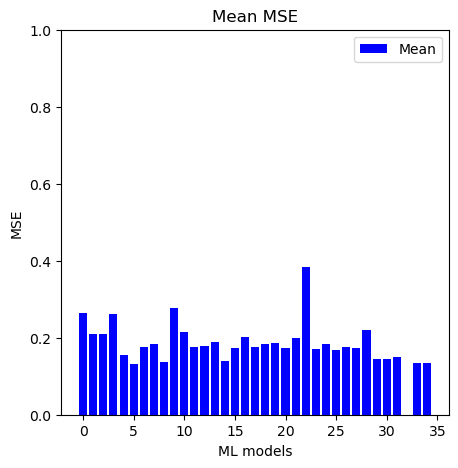

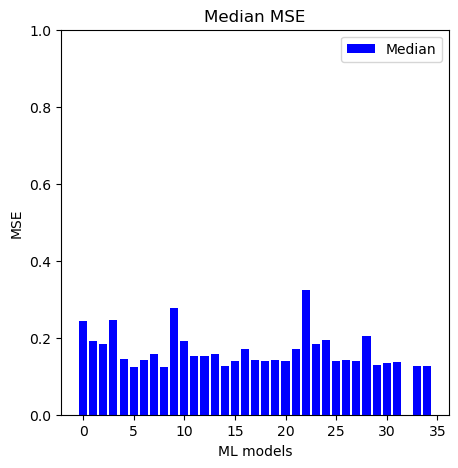

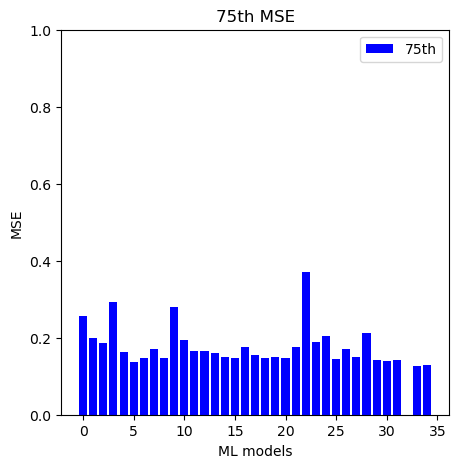

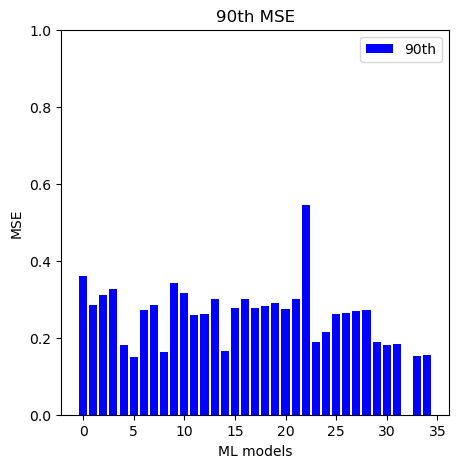

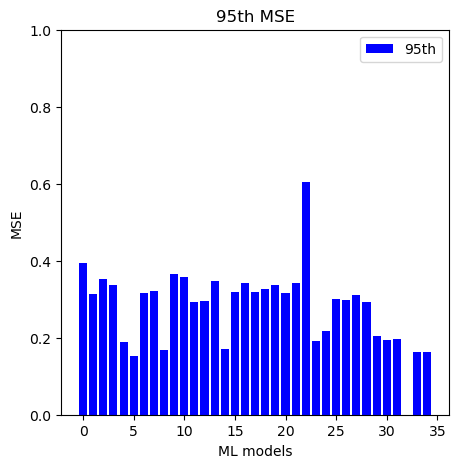

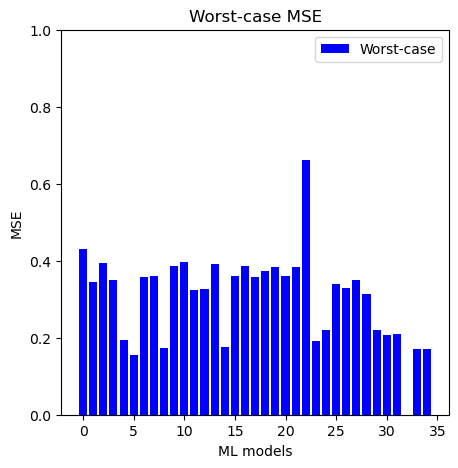

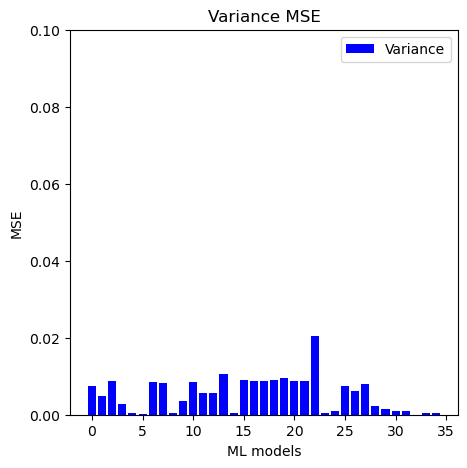

In [100]:
# display the statistica as bar plot

#plot the mean
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['mean'])), stats_mse_estimates['mean'], color='blue', label='Mean')
plt.title('Mean MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the median
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['median'])), stats_mse_estimates['median'], color='blue', label='Median')
plt.title('Median MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show() 

#plot the 75th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['75th'])), stats_mse_estimates['75th'], color='blue', label='75th')
plt.title('75th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 90th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['90th'])), stats_mse_estimates['90th'], color='blue', label='90th')
plt.title('90th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

#plot the 95th
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['95th'])), stats_mse_estimates['95th'], color='blue', label='95th')
plt.title('95th MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

# plot the worst-case
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['worst-case'])), stats_mse_estimates['worst-case'], color='blue', label='Worst-case')
plt.title('Worst-case MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()


# plot the variance
plt.figure(figsize=(5, 5))
plt.bar(range(len(stats_mse_estimates['variance'])), stats_mse_estimates['variance'], color='blue', label='Variance')
plt.title('Variance MSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0,0.1)
plt.legend()
plt.show()

# Metrics of the ForceSMIP challenge

### metric to evaluate the methods
### - long term trends: 1. uncetered pattern correlation: $r_i = \langle f_i, f_0 \rangle \lVert f_i \rVert^{-1}  \lVert f_0 \rVert^{-1}$ where $\lVert \cdot \rVert = p^{-1} \sqrt{\langle \cdot, \cdot \rangle}$ and $p$ is the total number of grid cells.
### - $RMSE = \lVert f_i - f_0 \rVert$ normalized by the amplitude of the forced response $\lVert f_0 \rVert$.
### -  amplitude ratio of the predicted and the true forced response pattern $\gamma_i = \frac{\lVert f_i \rVert}{\lVert f_0 \rVert}$

## It  turns out that $r_i = \frac{1+ \gamma_i^2 - \mathrm{nRMSE}_i^2}{2 \gamma_i}$

In [102]:
### Training dates 
years_train = np.arange(2100 - 1880 +1)

# year index to a scalar in [0,1]
years_train_idx_feature = years_train   # normalize to [0,1] range

# get index of years 1950 - 2022
years_test = years_train[(years_train >= 1950-1880) & (years_train <= 2022-1880)]

# do the computation for the test years 1980 - 2022
years_test_idx_feature =  years_test[30:]

# print("Training years:", years_train_idx_feature)
x_test_yearly_torch_tmp = x_test_yearly[:, 30:, :]
y_test_yearly_torch_tmp = y_test_yearly[:, 30:, :]

# compute yearly average of the predictions
y_pred_tmp = y_pred_yearly[:, 30:, :]
y_pred_low_rank_tmp = y_pred_lr_yearly[:, 30:, :]
y_pred_weighted_tmp = y_pred_weighted[:,30:,:]
y_pred_low_rank_weighted_tmp = y_pred_low_rank_weighted[:,30:,:]

data_estimates_yearly_torch = torch.from_numpy(data_estimates_yearly).to(torch.float32).reshape(data_estimates_yearly.shape[0], data_estimates_yearly.shape[1], data_estimates_yearly.shape[2],-1)  # reshape to (n_samples, time_length, n_features)
data_estimates_yearly_tmp = data_estimates_yearly_torch[:, :, 30:, :]

In [103]:
# compute the trend of y_pred
trend_pred = np.zeros((y_pred_tmp.shape[0], y_pred_tmp.shape[2]), dtype=np.float32)
for i in range(y_pred_tmp.shape[0]):
    trend_pred[i, :] = np.polyfit(np.arange(y_pred_tmp.shape[1]), y_pred_tmp[i, :, :], 1)[0]


# compute the trend of y_pred_weighted
trend_pred_weighted = np.zeros((y_pred_weighted_tmp.shape[0], y_pred_weighted_tmp.shape[2]), dtype=np.float32)
for i in range(y_pred_weighted_tmp.shape[0]):
    trend_pred_weighted[i, :] = np.polyfit(np.arange(y_pred_weighted_tmp.shape[1]), y_pred_weighted_tmp[i, :, :], 1)[0]

# compute the trend of y_pred_low_rank
trend_pred_weighted_low_rank = np.zeros((y_pred_low_rank_weighted_tmp.shape[0], y_pred_low_rank_weighted_tmp.shape[2]), dtype=np.float32)
for i in range(y_pred_low_rank_weighted_tmp.shape[0]):
    trend_pred_weighted_low_rank[i, notnan_idx] = np.polyfit(np.arange(y_pred_low_rank_weighted_tmp.shape[1]), y_pred_low_rank_weighted_tmp[i, :, notnan_idx], 1)[0]


# compute the trend of each estimates
trend_estimates = np.zeros((data_estimates_yearly_tmp.shape[0], data_estimates_yearly_tmp.shape[1], data_estimates_yearly_tmp.shape[3]), dtype=np.float32)
for i in range(data_estimates_yearly_tmp.shape[0]):
    for j in range(data_estimates_yearly_tmp.shape[1]):
        # Fit a linear trend to the data estimates for each model and each year
        # data_estimates_yearly[i, j, :] is the data estimates for model i and year j
        # np.polyfit returns the coefficients of the polynomial fit, we take the first coefficient (the slope)
        trend_estimates[i, j, notnan_idx] = np.polyfit(np.arange(data_estimates_yearly_tmp.shape[2]), data_estimates_yearly_tmp[i, j, :, notnan_idx], 1)[0]

# compute the trend of the target forced response
trend_forced_response = np.zeros((y_test_yearly_torch_tmp.shape[0], y_test_yearly_torch_tmp.shape[2]), dtype=np.float32)
for i in range(y_test_yearly_torch_tmp.shape[0]):
    # Fit a linear trend to the data estimates for each model and each year
    # y_test_yearly_torch_tmp[i, j, :] is the target forced response for model i and year j
    # np.polyfit returns the coefficients of the polynomial fit, we take the first coefficient (the slope)
    trend_forced_response[i, notnan_idx] = np.polyfit(np.arange(y_test_yearly_torch_tmp.shape[1]), y_test_yearly_torch_tmp[i, :, notnan_idx], 1)[0]

In [104]:
# 1. Compute normalized RMSE for each ensemble member in the test set
normalized_rmse = np.zeros((trend_pred.shape[0]) , dtype=np.float32)
normalized_rmse = np.linalg.norm((trend_pred[:,notnan_idx] - trend_forced_response[:,notnan_idx]), axis=1) / np.linalg.norm(trend_forced_response[:,notnan_idx], axis=1)

normalized_rmse_weighted = np.zeros((trend_pred_weighted.shape[0]) , dtype=np.float32)
normalized_rmse_weighted = np.linalg.norm((trend_pred_weighted[:,notnan_idx] - trend_forced_response[:,notnan_idx]), axis=1) / np.linalg.norm(trend_forced_response[:,notnan_idx], axis=1)

# compute the normalized MSE for all the methods
normalized_rmse_weighted_low_rank = np.zeros((trend_pred_weighted_low_rank.shape[0],) , dtype=np.float32)
normalized_rmse_weighted_low_rank = np.linalg.norm((trend_pred_weighted_low_rank[:,notnan_idx] - trend_forced_response[:,notnan_idx]), axis=1) / np.linalg.norm(trend_forced_response[:,notnan_idx], axis=1)

In [105]:
# compute the yearly mse of the other estimates 
# compute mse of the other estimates
normalized_rmse_estimates = np.zeros((trend_estimates.shape[0],trend_estimates.shape[1]) , dtype=np.float32)

for idx_r in range(trend_estimates.shape[0]):
    normalized_rmse_estimates[idx_r,:] = np.sqrt(np.nansum((trend_estimates[idx_r,:,notnan_idx].transpose(1,0) - trend_forced_response[:,notnan_idx])**2, axis=1) /np.nansum(trend_forced_response[:,notnan_idx]**2,axis=1))

In [106]:
amplitude_ratio = np.linalg.norm(trend_pred[:,notnan_idx], axis=1) / np.linalg.norm(trend_forced_response[:,notnan_idx], axis=1)
amplitude_ratio_weighted = np.linalg.norm(trend_pred_weighted[:,notnan_idx], axis=1) / np.linalg.norm(trend_forced_response[:,notnan_idx], axis=1)
amplitude_ratio_weighted_low_rank = np.linalg.norm(trend_pred_weighted_low_rank[:,notnan_idx], axis=1) / np.linalg.norm(trend_forced_response[:,notnan_idx], axis=1)

# compute the amplitude ratio for the other estimates
amplitude_ratio_estimates = np.zeros((trend_estimates.shape[0],trend_estimates.shape[1]) , dtype=np.float32)
for i in range(trend_estimates.shape[0]):
    amplitude_ratio_estimates[i,:] = np.sqrt(np.nansum(trend_estimates[i,:,notnan_idx].transpose(1,0)**2,axis=1) / np.nansum(trend_forced_response[:,notnan_idx]**2,axis=1))

In [107]:
pattern_corr = (1 + amplitude_ratio**2 - normalized_rmse**2) / (2 * amplitude_ratio)
pattern_corr_weighted = (1 + amplitude_ratio_weighted**2 - normalized_rmse_weighted**2) / (2 * amplitude_ratio_weighted)
pattern_corr_weighted_low_rank = (1 + amplitude_ratio_weighted_low_rank**2 - normalized_rmse_weighted_low_rank**2) / (2 * amplitude_ratio_weighted_low_rank)

pattern_corr_estimates = np.zeros((trend_estimates.shape[0],trend_estimates.shape[1]) , dtype=np.float32)
for i in range(trend_estimates.shape[0]):
    pattern_corr_estimates[i] = (1 + amplitude_ratio_estimates[i,:]**2 - normalized_rmse_estimates[i,:]**2) / (2 * amplitude_ratio_estimates[i,:])

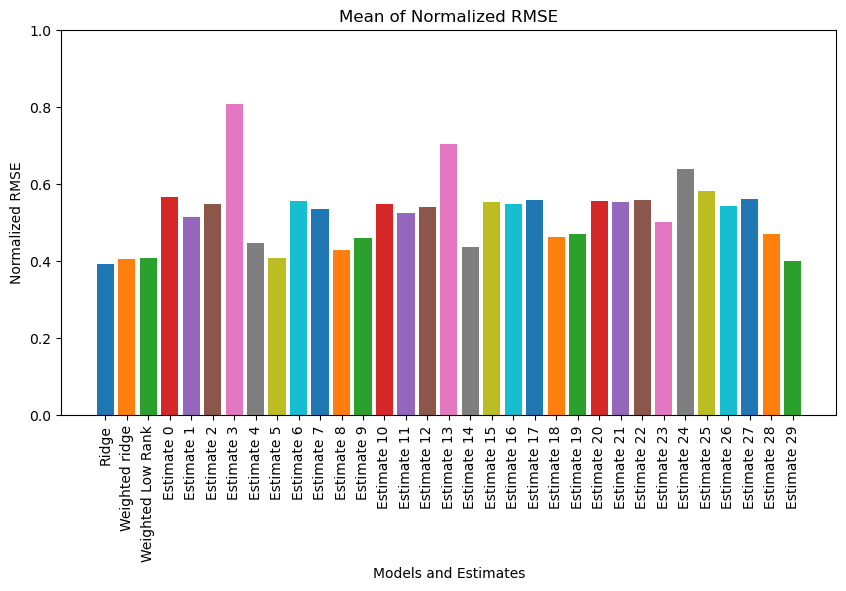

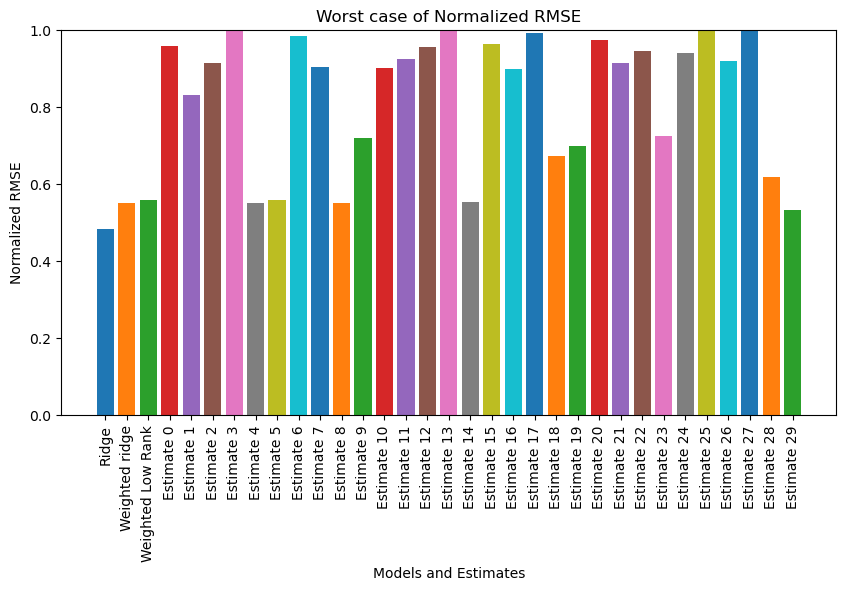

In [108]:
# display the statistics as bar plot
nrmse = {
    'Ridge': normalized_rmse,
    'Weighted ridge': normalized_rmse_weighted,
    'Weighted Low Rank': normalized_rmse_weighted_low_rank
}
for i in range(normalized_rmse_estimates.shape[0]):
    nrmse[f'Estimate {i}'] = normalized_rmse_estimates[i,:]

# Plotting the mean normalized RMSE
plt.figure(figsize=(10, 5))
for label, values in nrmse.items():
    plt.bar(label, np.sqrt(np.mean(values**2)), label=label)
plt.title('Mean of Normalized RMSE')
plt.xlabel('Models and Estimates')
plt.ylabel('Normalized RMSE')
plt.ylim(0, 1)
plt.xticks(rotation=90)
# plt.legend()
plt.show()


plt.figure(figsize=(10, 5))
for label, values in nrmse.items():
    plt.bar(label, np.sqrt(np.max(values**2)), label=label)
plt.title('Worst case of Normalized RMSE')
plt.xlabel('Models and Estimates')
plt.ylabel('Normalized RMSE')
plt.ylim(0, 1)
plt.xticks(rotation=90)
# plt.legend()
plt.show()

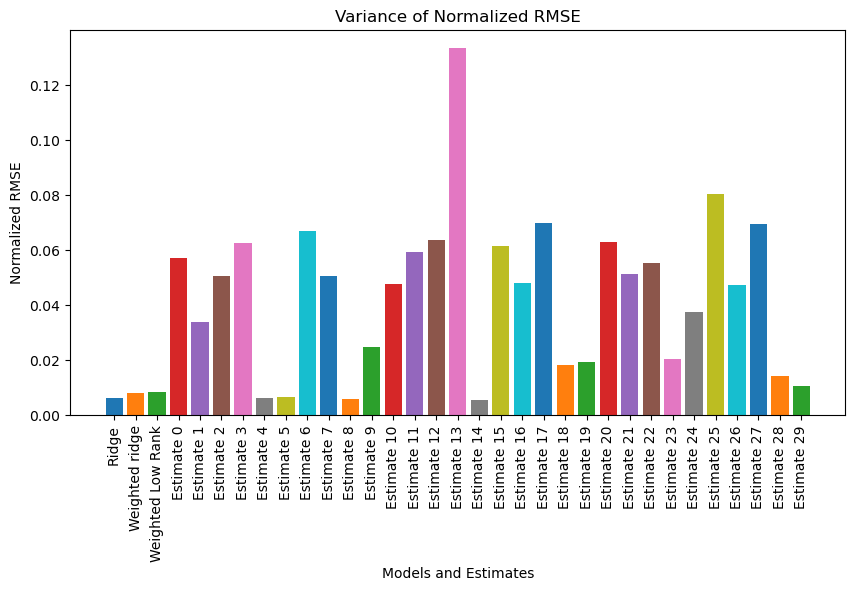

In [111]:
# display variance of the normalized RMSE
plt.figure(figsize=(10, 5))
for label, values in nrmse.items():
    plt.bar(label, np.var(values), label=label)
plt.title('Variance of Normalized RMSE')
plt.xlabel('Models and Estimates')
plt.ylabel('Normalized RMSE')
# plt.ylim(0,)
plt.xticks(rotation=90)
# plt.legend()
plt.show()

In [109]:
# get the key of the best model
best_model_key = min(nrmse, key=lambda k: np.sqrt(np.mean(nrmse[k]**2)))
print(f'Best model based on normalized RMSE: {best_model_key}')

Best model based on normalized RMSE: Ridge


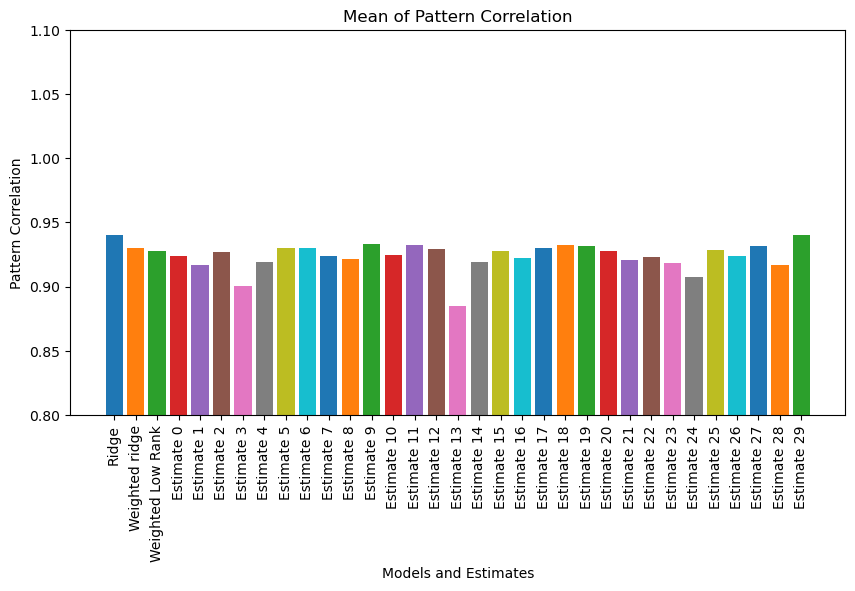

In [112]:
# plotting the pattern correlation
pattern = {
    'Ridge': pattern_corr,
    'Weighted ridge': pattern_corr_weighted,
    'Weighted Low Rank': pattern_corr_weighted_low_rank
} 
for i in range(pattern_corr_estimates.shape[0]):
    pattern[f'Estimate {i}'] = pattern_corr_estimates[i,:]


# Plotting the mean pattern correlation
plt.figure(figsize=(10, 5))
for label, values in pattern.items():
    plt.bar(label, np.sqrt(np.mean(values**2)), label=label)
plt.title('Mean of Pattern Correlation')
plt.xlabel('Models and Estimates')
plt.ylabel('Pattern Correlation')
plt.ylim(0.8, 1.1)
plt.xticks(rotation=90)
# plt.legend()
plt.show()

In [113]:
# get the best pattern correlation
best_pattern_key = max(pattern, key=lambda k: np.sqrt(np.mean(pattern[k]**2)))
print(f'Best model based on pattern correlation: {best_pattern_key}')

Best model based on pattern correlation: Estimate 29


In [114]:
pattern_corr_mean = np.zeros((len(pattern.keys()),), dtype=np.float32)
for idx, key in enumerate(pattern.keys()):
    pattern_corr_mean[idx] = np.sqrt(np.mean(pattern[key]**2))

In [115]:
pattern_corr_mean

array([0.93988943, 0.9296881 , 0.9276026 , 0.923515  , 0.91649973,
       0.9268695 , 0.90042466, 0.9193479 , 0.9303242 , 0.9299694 ,
       0.9238049 , 0.9217916 , 0.9329789 , 0.92465496, 0.93226993,
       0.9293769 , 0.88458174, 0.9190637 , 0.92775905, 0.9223343 ,
       0.92991734, 0.93218285, 0.9316011 , 0.9277466 , 0.92080307,
       0.9227577 , 0.91848475, 0.9071656 , 0.9285453 , 0.9236737 ,
       0.9315496 , 0.9168005 , 0.940513  ], dtype=float32)

# Display some maps

In [128]:
# assign nans
trend_pred[:, nan_idx] = np.nan

([<matplotlib.axis.YTick at 0x7f8a6c35d070>,
 [Text(0, 0, '-88.75'),
  Text(0, 10, '-63.75'),
  Text(0, 20, '-38.75'),
  Text(0, 30, '-13.75'),
  Text(0, 40, '11.25'),
  Text(0, 50, '36.25'),
  Text(0, 60, '61.25'),
  Text(0, 70, '86.25')])

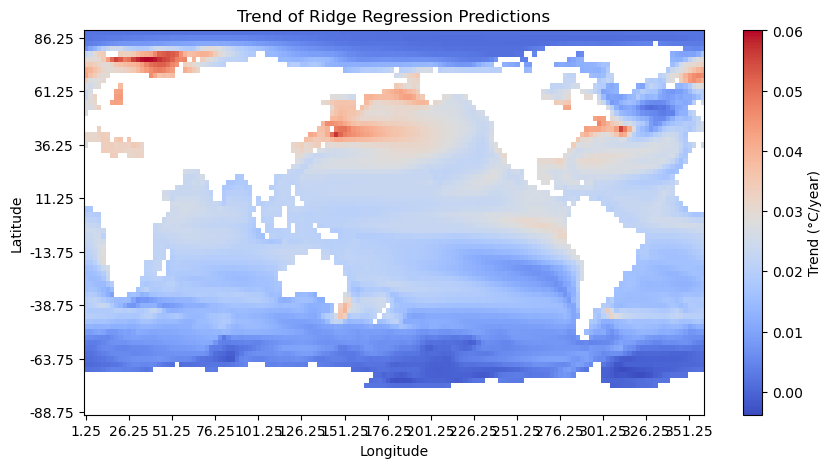

In [129]:
# display the map of the long-term trend of the predictions
plt.figure(figsize=(10, 5))
plt.imshow(trend_pred[0, :].reshape(latitude.shape[0], longitude.shape[0]), cmap='coolwarm', aspect='auto',origin='lower')
plt.colorbar(label='Trend (°C/year)')
plt.title('Trend of Ridge Regression Predictions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xticks(ticks=np.arange(0, longitude.shape[0], 10), labels=np.round(longitude[::10], 2))
plt.yticks(ticks=np.arange(0, latitude.shape[0], 10), labels=np.round(latitude[::10], 2))  

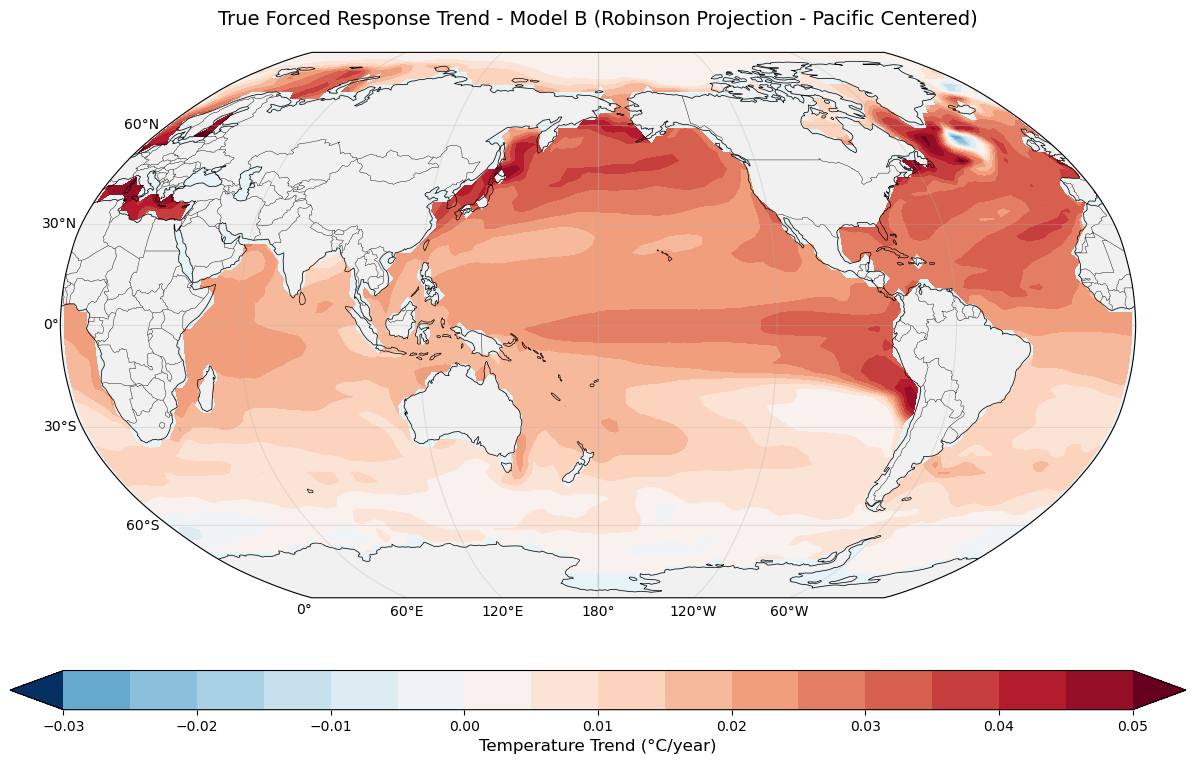

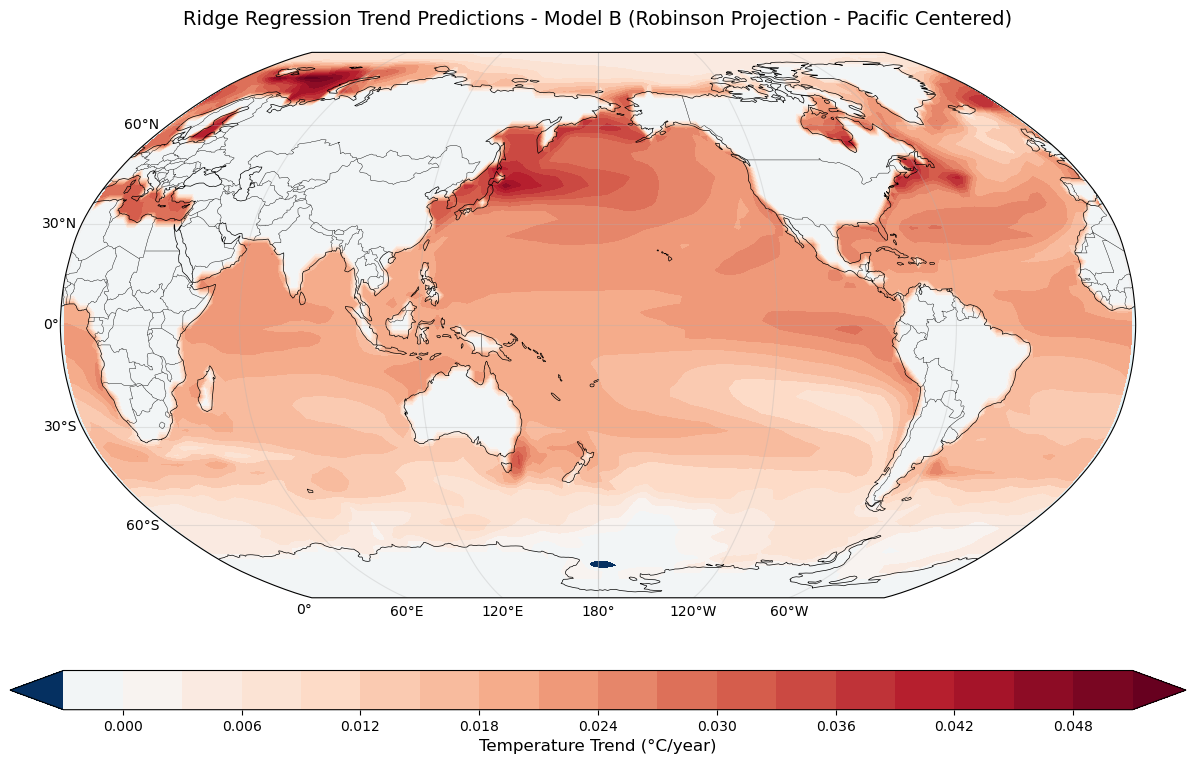

In [143]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

def plot_global_trend_map(trend_data, longitude, latitude, title="Global Temperature Trend", 
                         cmap='RdBu_r', vmin=None, vmax=None, run_idx=0):
    """
    Plot temperature trend data on a global map with proper projection
    
    Args:
        trend_data: numpy array of shape (n_runs, n_grid_points)
        longitude: 1D array of longitude values
        latitude: 1D array of latitude values
        title: plot title
        cmap: colormap
        vmin, vmax: color scale limits
        run_idx: which run to plot
    """
    # Reshape trend data to 2D grid
    trend_2d = trend_data[run_idx, :].reshape(latitude.shape[0], longitude.shape[0])
    
    # Create meshgrid for plotting
    lon_2d, lat_2d = np.meshgrid(longitude, latitude)
    
    # Set color limits if not provided
    if vmin is None or vmax is None:
        vmax = np.nanmax(np.abs(trend_2d))
        vmin = -vmax
    
    # Create figure with orthographic projection (globe view)
    fig = plt.figure(figsize=(12, 8))
    
    # Left subplot - Pacific centered
    ax1 = fig.add_subplot(121, projection=ccrs.Orthographic(central_longitude=180))
    ax1.set_global()
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax1.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax1.gridlines(draw_labels=False, alpha=0.3)
    
    im1 = ax1.contourf(lon_2d, lat_2d, trend_2d, 
                       levels=20, cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(), extend='both')
    ax1.set_title(f'{title} - Pacific View')
    
    # Right subplot - Atlantic centered  
    ax2 = fig.add_subplot(122, projection=ccrs.Orthographic(central_longitude=0))
    ax2.set_global()
    ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax2.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax2.gridlines(draw_labels=False, alpha=0.3)
    
    im2 = ax2.contourf(lon_2d, lat_2d, trend_2d,
                       levels=20, cmap=cmap, vmin=vmin, vmax=vmax, 
                       transform=ccrs.PlateCarree(), extend='both')
    ax2.set_title(f'{title} - Atlantic View')
    
    # Add colorbar
    cbar = fig.colorbar(im1, ax=[ax1, ax2], orientation='horizontal', 
                       pad=0.1, shrink=0.8, aspect=30)
    cbar.set_label('Temperature Trend (°C/year)', fontsize=12)
    
    plt.suptitle(f'{title} - Model {lst_test_name[run_idx]}', fontsize=14, y=0.95)
    plt.tight_layout()
    plt.show()
    
    return fig

def plot_robinson_projection(trend_data, longitude, latitude, title="Global Temperature Trend",
                           cmap='RdBu_r', vmin=None, vmax=None, run_idx=0, central_longitude=180):
    """
    Plot data using Robinson projection (good for global overview)
    
    Args:
        trend_data: numpy array of shape (n_runs, n_grid_points)
        longitude: 1D array of longitude values
        latitude: 1D array of latitude values
        title: plot title
        cmap: colormap
        vmin, vmax: color scale limits
        run_idx: which run to plot
        central_longitude: longitude to center the projection on (180 for Pacific, 0 for Atlantic)
    """
    # Reshape trend data to 2D grid
    trend_2d = trend_data[run_idx, :].reshape(latitude.shape[0], longitude.shape[0])
    
    # Create meshgrid for plotting
    lon_2d, lat_2d = np.meshgrid(longitude, latitude)
    
    # Set color limits if not provided
    if vmin is None or vmax is None:
        vmax = np.nanmax(np.abs(trend_2d))
        vmin = -vmax
    
    # Create figure with Robinson projection centered on Pacific
    fig = plt.figure(figsize=(15, 8))
    ax = fig.add_subplot(111, projection=ccrs.Robinson(central_longitude=central_longitude))
    
    ax.set_global()
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
    ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)
    
    # Plot the data
    im = ax.contourf(lon_2d, lat_2d, trend_2d,
                     levels=20, cmap=cmap, vmin=vmin, vmax=vmax,
                     transform=ccrs.PlateCarree(), extend='both')
    
    # Add gridlines
    gl = ax.gridlines(draw_labels=True, alpha=0.3)
    gl.top_labels = False
    gl.right_labels = False
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal',
                       pad=0.1, shrink=0.8, aspect=30)
    cbar.set_label('Temperature Trend (°C/year)', fontsize=12)
    
    plt.title(f'{title} - Model {lst_test_name[run_idx]} (Robinson Projection - Pacific Centered)', 
              fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
    
    return fig


# Usage examples:

# # 1. Display ridge regression predictions as globe
# plot_global_trend_map(trend_pred, longitude, latitude, 
#                      title="Ridge Regression Trend Predictions", 
#                      run_idx=0)

# # 2. Display weighted predictions as globe  
# plot_global_trend_map(trend_pred_weighted, longitude, latitude,
#                      title="Weighted Ridge Regression Trend Predictions",
#                      run_idx=0)

# 3. Display ground truth as Robinson projection centered on Pacific
plot_robinson_projection(trend_forced_response, longitude, latitude,
                        title="True Forced Response Trend",
                        run_idx=0, central_longitude=180)

# # 4. Display ground truth as Robinson projection centered on Atlantic (for comparison)
# plot_robinson_projection(trend_forced_response, longitude, latitude,
#                         title="True Forced Response Trend",
#                         run_idx=0, central_longitude=0)

# 5. Display your ridge regression predictions with Pacific-centered Robinson projection
plot_robinson_projection(trend_pred_weighted, longitude, latitude,
                        title="Ridge Regression Trend Predictions",
                        run_idx=0, central_longitude=180)

# 4. Compare multiple models side by side
def compare_models_globe(data_dict, longitude, latitude, suptitle="Model Comparison"):
    """Compare multiple models on globe projections"""
    n_models = len(data_dict)
    fig = plt.figure(figsize=(15, 4*n_models))
    
    for idx, (model_name, trend_data) in enumerate(data_dict.items()):
        # Pacific view
        ax1 = fig.add_subplot(n_models, 2, 2*idx + 1, 
                             projection=ccrs.Orthographic(central_longitude=180))
        ax1.set_global()
        ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
        
        trend_2d = trend_data[0, :].reshape(latitude.shape[0], longitude.shape[0])
        lon_2d, lat_2d = np.meshgrid(longitude, latitude)
        
        vmax = np.nanmax(np.abs(trend_2d))
        im1 = ax1.contourf(lon_2d, lat_2d, trend_2d,
                          levels=20, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                          transform=ccrs.PlateCarree(), extend='both')
        ax1.set_title(f'{model_name} - Pacific')
        
        # Atlantic view
        ax2 = fig.add_subplot(n_models, 2, 2*idx + 2,
                             projection=ccrs.Orthographic(central_longitude=0))
        ax2.set_global()
        ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
        
        im2 = ax2.contourf(lon_2d, lat_2d, trend_2d,
                          levels=20, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                          transform=ccrs.PlateCarree(), extend='both')
        ax2.set_title(f'{model_name} - Atlantic')
        
        # Add colorbar for each row
        cbar = fig.colorbar(im1, ax=[ax1, ax2], orientation='horizontal',
                           pad=0.1, shrink=0.8, aspect=30)
        cbar.set_label('Trend (°C/year)')
    
    plt.suptitle(suptitle, fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Compare different methods
model_comparison = {
    'Ridge Regression': trend_pred,
    'Weighted Ridge': trend_pred_weighted, 
    'Ground Truth': trend_forced_response
}

# compare_models_globe(model_comparison, longitude, latitude,
#                     "Temperature Trend Comparison")

Displaying triple comparison (Ground Truth vs Ridge Prediction vs Test Member):


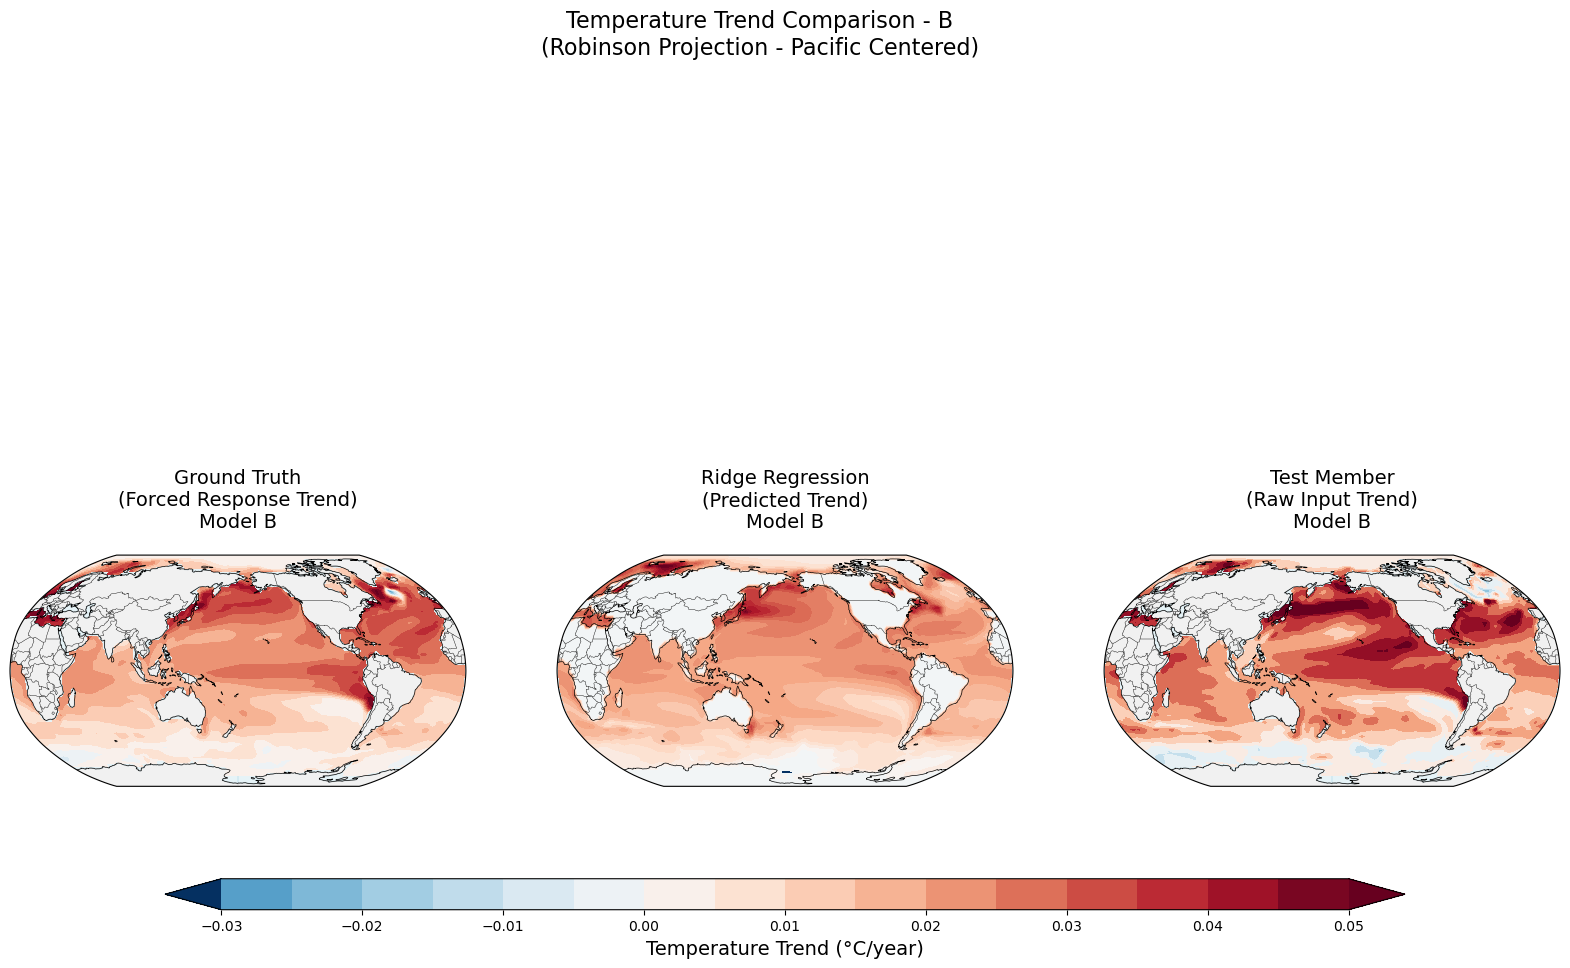

In [150]:
# Display Robinson projections for comparison
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# First, let's compute the trend of the test member (raw input data)
trend_test_member = np.zeros((x_test_yearly_torch_tmp.shape[0], x_test_yearly_torch_tmp.shape[2]), dtype=np.float32)
for i in range(x_test_yearly_torch_tmp.shape[0]):
    trend_test_member[i, notnan_idx] = np.polyfit(np.arange(x_test_yearly_torch_tmp.shape[1]), x_test_yearly_torch_tmp[i, :, notnan_idx], 1)[0]

# Assign NaNs to land areas for all trend data
trend_test_member[:, nan_idx] = np.nan
trend_forced_response[:, nan_idx] = np.nan
trend_pred[:, nan_idx] = np.nan

def plot_triple_robinson_comparison(trend_forced, trend_ridge, trend_test, longitude, latitude, 
                                  run_idx=0, central_longitude=180, cmap='RdBu_r'):
    """
    Plot three Robinson projections side by side for comparison
    """
    # Reshape all trend data to 2D grids
    trend_forced_2d = trend_forced[run_idx, :].reshape(latitude.shape[0], longitude.shape[0])
    trend_ridge_2d = trend_ridge[run_idx, :].reshape(latitude.shape[0], longitude.shape[0])
    trend_test_2d = trend_test[run_idx, :].reshape(latitude.shape[0], longitude.shape[0])
    
    # Create meshgrid for plotting
    lon_2d, lat_2d = np.meshgrid(longitude, latitude)
    
    # Set common color limits based on forced response
    vmax = 0.05
    vmin = -0.05
    
    # Create figure with three subplots
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Ground Truth (Forced Response)
    ax1 = fig.add_subplot(131, projection=ccrs.Robinson(central_longitude=central_longitude))
    ax1.set_global()
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax1.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax1.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
    ax1.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)
    
    im1 = ax1.contourf(lon_2d, lat_2d, trend_forced_2d,
                       levels=20, cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(), extend='both')
    ax1.set_title(f'Ground Truth\n(Forced Response Trend)\nModel {lst_test_name[run_idx]}', 
                  fontsize=14, pad=20)
    
    # 2. Ridge Regression Prediction
    ax2 = fig.add_subplot(132, projection=ccrs.Robinson(central_longitude=central_longitude))
    ax2.set_global()
    ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax2.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax2.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
    ax2.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)
    
    im2 = ax2.contourf(lon_2d, lat_2d, trend_ridge_2d,
                       levels=20, cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(), extend='both')
    ax2.set_title(f'Ridge Regression\n(Predicted Trend)\nModel {lst_test_name[run_idx]}', 
                  fontsize=14, pad=20)
    
    # 3. Test Member (Raw Input)
    ax3 = fig.add_subplot(133, projection=ccrs.Robinson(central_longitude=central_longitude))
    ax3.set_global()
    ax3.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax3.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax3.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
    ax3.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)
    
    im3 = ax3.contourf(lon_2d, lat_2d, trend_test_2d,
                       levels=20, cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(), extend='both')
    ax3.set_title(f'Test Member\n(Raw Input Trend)\nModel {lst_test_name[run_idx]}', 
                  fontsize=14, pad=20)
    
    # Add common colorbar
    cbar = fig.colorbar(im1, ax=[ax1, ax2, ax3], orientation='horizontal',
                       pad=0.1, shrink=0.8, aspect=40)
    cbar.set_label('Temperature Trend (°C/year)', fontsize=14)
  
    plt.suptitle(f'Temperature Trend Comparison - {lst_test_name[run_idx]}\n(Robinson Projection - Pacific Centered)', 
                 fontsize=16, y=0.95)
    # plt.tight_layout()
    plt.show()
    
    # return fig

plt.close('all')  # Close any previous plots

# Display comparisons for the first test case (run_idx=0)
print("Displaying triple comparison (Ground Truth vs Ridge Prediction vs Test Member):")
plot_triple_robinson_comparison(trend_forced_response, trend_pred_weighted_low_rank, trend_test_member, 
                               longitude, latitude, run_idx=0, central_longitude=180)
